Connect libraries

In [2]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import cv2

Making data_set

In [3]:
class_path = '/teamspace/studios/this_studio/oxford_102/flower_data/cat_to_name.json'
with open(class_path, "r") as file:
    classes = json.load(file)
classes = {int(k): v for k, v in classes.items()}
classes = dict(sorted(classes.items()))

In [4]:
train_path = '/teamspace/studios/this_studio/oxford_102/flower_data/train'

#TRAIN_DATASET
df_image_train = pd.DataFrame(columns=["class_index", "path"])

# CLASSES
df_classes = pd.DataFrame(list(classes.items()), columns = ['class_index', 'class_name'])

for _, row in df_classes.iterrows():
    train_flower_folder = os.path.join(train_path, str(row['class_index']))
    files = os.listdir(train_flower_folder)
    paths_to_images = [os.path.join(train_flower_folder, img) for img in files]
    df_images = pd.DataFrame({"class_index": [row['class_index'] for _ in range(len(paths_to_images))],
                              "path": paths_to_images})
    df_image_train = pd.concat([df_image_train, df_images], ignore_index=True)

In [11]:
df_image_train.sample(5)

,class_index,path
4670,77,/teamspace/studios/this_studio/oxford_102/flow...
3407,60,/teamspace/studios/this_studio/oxford_102/flow...
2108,43,/teamspace/studios/this_studio/oxford_102/flow...
4020,72,/teamspace/studios/this_studio/oxford_102/flow...
4949,81,/teamspace/studios/this_studio/oxford_102/flow...


In [6]:
def draw(paths, class_names=None):
    '''Draw multiple images in a grid with exactly 3 columns'''
    if isinstance(paths, str):
        paths = [paths]
        class_names = [class_names] if class_names else None
    rows = (len(paths) + 2) // 3 
    
    fig, axes = plt.subplots(rows, 3, figsize=(12, 4 * rows))
    axes = axes.flatten()
    
    for i in range(len(axes)):
        if i < len(paths):
            image_rgb = cv2.cvtColor(cv2.imread(paths[i]), cv2.COLOR_BGR2RGB)
            axes[i].imshow(image_rgb)
            if class_names is not None:
                axes[i].set_title(class_names[i])
        axes[i].axis('off')
    plt.show()

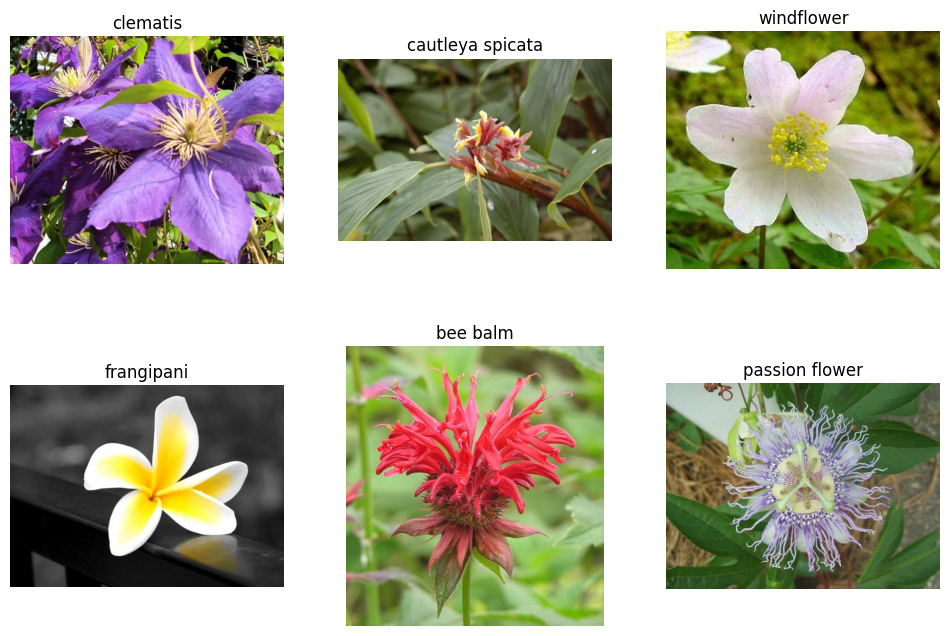

In [7]:
img_df, names_list = df_image_train.sample(6), []
for class_idx in img_df['class_index']:
    name = df_classes[df_classes['class_index'] == class_idx]['class_name'].iloc[0]
    names_list.append(name)
draw(img_df['path'].tolist(), names_list)

In [13]:
valid_path = '/teamspace/studios/this_studio/oxford_102/flower_data/valid'

#VALID_DATASET
df_image_valid = pd.DataFrame(columns=["class_index", "path"])

for _, row in df_classes.iterrows():
    train_flower_folder = os.path.join(train_path, str(row['class_index']))
    files = os.listdir(train_flower_folder)
    paths_to_images = [os.path.join(train_flower_folder, img) for img in files]
    df_images = pd.DataFrame({"class_index": [row['class_index'] for _ in range(len(paths_to_images))],
                              "path": paths_to_images})
    df_image_valid = pd.concat([df_image_valid, df_images], ignore_index=True)

In [14]:
df_image_valid.sample(5)

,class_index,path
4761,78,/teamspace/studios/this_studio/oxford_102/flow...
6496,101,/teamspace/studios/this_studio/oxford_102/flow...
1848,40,/teamspace/studios/this_studio/oxford_102/flow...
244,6,/teamspace/studios/this_studio/oxford_102/flow...
5590,89,/teamspace/studios/this_studio/oxford_102/flow...


In [ ]:
test_path = '/teamspace/studios/this_studio/oxford_102/flower_data/test'